# recs_012 — Causal training rows + two-tower grid (TensorFlow)

**Goal:** Build causal `(anchor review → future liked apps)` training rows, then compare a **2×2 grid** of user/item **input recipes** before the shared trainable `Dense(proj_dim)` heads. Pick a winner → export → `recs_job_eval_retrieval`.

## Two-tower grid (same loss, same heads)

Each run learns **user_projection** and **item_projection** (default 64-d) with the same contrastive loss (symmetric multi-positive in-batch InfoNCE).

| Label | User input path | Item input path |
|-------|------------------|------------------|
| `frozen_user__frozen_recs002_item` | Frozen `USE(anchor)` → trainable user head | Frozen `recs_002` item vectors → trainable item head |
| `frozen_user__updated_profile200_item` | Frozen `USE(anchor)` → trainable user head | Init from mean-pooled `USE(review)` (up to 200 reviews/game), then item embeddings update during training |
| `updated_user__frozen_recs002_item` | Hub-in-graph `USE(anchor)` with `trainable=True` → trainable user head | Frozen `recs_002` item vectors → trainable item head |
| `updated_user__updated_profile200_item` | Hub-in-graph `USE(anchor)` with `trainable=True` → trainable user head | Init from mean-pooled `USE(review)` (up to 200 reviews/game), then item embeddings update during training |

For `updated_profile200`, apps missing profile reviews fall back to their `recs_002` vector so catalog coverage stays complete.

**What the grid isolates**

- **frozen vs updated user:** frozen = offline `embed_text`; updated = Hub in `fit` with `trainable=True` on the user encoder.
- **frozen vs updated item:** frozen = fixed `recs_002` item vectors; updated = trainable item embedding table initialized from profile mean vectors (200-review cap).

## Anchors & labels

| Anchor style | Notes |
|--------------|-------|
| **Per-review (default)** | State = thumbs-up with `(ts, rid)` strictly before anchor; labels = distinct apps liked strictly after. |

Rows with zero future positives are dropped for tower training.

## Config & validation

**Edit one place:** `Recs012Config` — `tower_grid_to_run`, `training_mode` (`smoke` | `full`), caps, epochs, `k_retrieval`, `max_val_anchors_eval`.

**Training** uses causal rows + **`val_loss`** (contrastive loss on held-out causal val rows) for early stopping only.

**Winner selection (post-training, step 2)** uses cached **Task A** examples (`artifacts/recs/eval_cache/val_dev_12k_v1/eval_examples.parquet`) — same benchmark as `recs_job_eval_retrieval.py`, **not** `val_loss`:

- **`k_retrieval`** from `configs/recs_job_eval_retrieval.json` (default **100**).
- **Slice A** (`n_eval_targets ≥ 2`): primary **Recall@K**; secondary Precision@K; tie-break Hit@K.
- **Slice B** (`n_eval_targets == 1`): primary **Hit@K**; secondary Precision@K; tie-break Recall@K.
- Report **`train_support_bucket`** (`n_support_train` from attached train reviews).

After training: score towers on the cached parquet vs full catalog (+ USE baseline). Pick the grid cell with best slice-A Recall@K; check slice-B and support buckets.

**Scale:** `max_users_anchor=None` materializes all users with ≥1 thumbs-up (slow). Use an integer for dev; `max_rows_tower` caps supervised anchors per split.


In [1]:
from __future__ import annotations

import json
from dataclasses import dataclass, field
from pathlib import Path
from typing import Literal

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

from steam_review_ml.data.loaders import (
    NORMALIZED_SPLIT_FILENAMES,
    SPLIT_TRAIN,
    SPLIT_VAL,
    load_normalized_split_df,
    resolve_normalized_split_parquet,
)
from steam_review_ml.evaluation.retrieval_offline_eval import (
    MASKING_POLICY_VERSION,
    RETRIEVAL_METRIC_COLS,
    USER_COL,
    _embedding_model_snapshot,
    _per_example_retrieval_ranking,
    _table_by_slice_for_metrics,
    _table_by_support_for_metrics,
    hit_rate_at_k,
    precision_at_k,
    prepare_eval_inputs_from_cache,
    recall_at_k,
)
from steam_review_ml.recommender.math_utils import l2_normalize
from steam_review_ml.recommender.retrieve import ContentRetriever

UserMode = Literal["frozen", "updated"]
ItemMode = Literal["frozen_recs002", "updated_profile200"]
TrainingMode = Literal["smoke", "full"]


@dataclass(frozen=True)
class TowerSpec:
    user_mode: UserMode
    item_mode: ItemMode

    @property
    def label(self) -> str:
        return f"{self.user_mode}_user__{self.item_mode}_item"


FULL_TOWER_GRID: tuple[TowerSpec, ...] = (
    TowerSpec("frozen", "frozen_recs002"),
    TowerSpec("frozen", "updated_profile200"),
    TowerSpec("updated", "frozen_recs002"),
    TowerSpec("updated", "updated_profile200"),
)


def find_repo_root(start: Path | None = None) -> Path:
    here = (start or Path.cwd()).resolve()
    for parent_dir in (here, *here.parents):
        if (parent_dir / "pyproject.toml").is_file():
            return parent_dir
    raise RuntimeError(f"No pyproject.toml above {here}")


@dataclass
class Recs012Config:
    """Single place to tune this notebook (no scattered globals)."""

    repo_root: Path = field(default_factory=lambda: find_repo_root())
    min_review_chars: int = 30
    max_users_anchor: int | None = 20_000
    random_seed: int = 2026
    write_anchors_parquet: bool = False
    anchors_parquet_relative: str = "artifacts/recs/training_rows/anchors_per_review_train.parquet"
    game_profile_reviews_relative: str = (
        "artifacts/recs/embeddings/game_profile/default/game_profile_reviews.parquet"
    )
    max_profile_reviews_per_game: int = 200
    profile_embed_batch_size: int = 128
    # --- tower training (2x2 grid) ---
    training_mode: TrainingMode = "full"
    tower_grid_to_run: tuple[tuple[UserMode, ItemMode], ...] = (
        ("frozen", "frozen_recs002"),
        ("frozen", "updated_profile200"),
        ("updated", "frozen_recs002"),
        ("updated", "updated_profile200"),
    )
    max_rows_tower: int = 10_000
    batch_size: int = 64
    proj_dim: int = 64
    temperature: float = 0.07
    epochs: int = 15
    smoke_epochs: int = 5
    early_stopping_patience: int = 3
    tower_seed: int = 2026
    adam_lr: float = 1e-3
    # updated user_mode always sets Hub trainable=True (see train_tower_spec). No separate flag.
    # --- Task A retrieval eval (post-training; not val_loss) ---
    k_retrieval: int = 100  # match configs/recs_job_eval_retrieval.json (eval contract v2)
    k_final: int = 10  # ranking depth for _per_example_retrieval_ranking (retrieval metrics use k_retrieval)
    eval_examples_parquet_relative: str = (
        "artifacts/recs/eval_cache/val_dev_12k_v1/eval_examples.parquet"
    )
    max_task_a_examples_eval: int | None = None  # None = all examples in parquet
    catalog_item_batch: int = 256
    mask_anchor_app_in_scores: bool = True

    @property
    def train_parquet(self) -> Path:
        return self.repo_root / "data" / "processed" / NORMALIZED_SPLIT_FILENAMES["train"]

    @property
    def anchors_parquet_path(self) -> Path:
        return self.repo_root / Path(self.anchors_parquet_relative)

    @property
    def game_profile_reviews_parquet(self) -> Path:
        return self.repo_root / Path(self.game_profile_reviews_relative)

    @property
    def eval_examples_parquet(self) -> Path:
        return self.repo_root / Path(self.eval_examples_parquet_relative)

    def resolve_tower_specs(self) -> tuple[TowerSpec, ...]:
        return tuple(TowerSpec(user_mode=user_mode, item_mode=item_mode) for user_mode, item_mode in self.tower_grid_to_run)


CFG = Recs012Config(
    training_mode="full",
    tower_grid_to_run=(
        ("frozen", "frozen_recs002"),
        ("frozen", "updated_profile200"),
        ("updated", "frozen_recs002"),
        ("updated", "updated_profile200"),
    ),
)
processed_data_dir = CFG.repo_root / "data" / "processed"
val_parquet_path, val_split_resolved = resolve_normalized_split_parquet(processed_data_dir, SPLIT_VAL)
print("repo_root:", CFG.repo_root)
print("train_parquet exists:", CFG.train_parquet.is_file(), CFG.train_parquet)
print(
    "val parquet (resolved):",
    val_split_resolved,
    val_parquet_path.is_file(),
    val_parquet_path,
)
print("game_profile_reviews:", CFG.game_profile_reviews_parquet.is_file(), CFG.game_profile_reviews_parquet)
print("eval_examples_parquet:", CFG.eval_examples_parquet.is_file(), CFG.eval_examples_parquet)
_eval_job_path = CFG.repo_root / "configs" / "recs_job_eval_retrieval.json"
if _eval_job_path.is_file():
    CFG.k_retrieval = int(json.loads(_eval_job_path.read_text(encoding="utf-8"))["k_retrieval"])
print("training_mode:", CFG.training_mode)
print("tower grid:", [s.label for s in CFG.resolve_tower_specs()])
print("k_retrieval (eval contract):", CFG.k_retrieval, "from", _eval_job_path if _eval_job_path.is_file() else "default")
print("max_rows_tower:", CFG.max_rows_tower, "epochs:", CFG.epochs)


/home/ryanr/miniconda3/envs/tf_condaforge/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


repo_root: /home/ryanr/workspace/steam_recommendations
train_parquet exists: True /home/ryanr/workspace/steam_recommendations/data/processed/steam_reviews_cleaned_english_train_norm.parquet
val parquet (resolved): val True /home/ryanr/workspace/steam_recommendations/data/processed/steam_reviews_cleaned_english_val_norm.parquet
game_profile_reviews: True /home/ryanr/workspace/steam_recommendations/artifacts/recs/embeddings/game_profile/default/game_profile_reviews.parquet
eval_examples_parquet: True /home/ryanr/workspace/steam_recommendations/artifacts/recs/eval_cache/val_dev_12k_v1/eval_examples.parquet
training_mode: full
tower grid: ['frozen_user__frozen_recs002_item', 'frozen_user__updated_profile200_item', 'updated_user__frozen_recs002_item', 'updated_user__updated_profile200_item']
k_retrieval (eval contract): 100 from /home/ryanr/workspace/steam_recommendations/configs/recs_job_eval_retrieval.json
max_rows_tower: 10000 epochs: 15


In [2]:
def load_retriever_and_train(cfg: Recs012Config) -> tuple[ContentRetriever, pd.DataFrame]:
    """ContentRetriever (indexed apps) + filtered train split (same contract as offline eval)."""
    retriever = ContentRetriever(repo_root=cfg.repo_root)
    indexed_app_ids = set(int(app_id) for app_id in retriever.app_ids.tolist())
    if not cfg.train_parquet.is_file():
        raise FileNotFoundError(cfg.train_parquet)
    train_reviews = load_normalized_split_df(
        cfg.train_parquet,
        indexed_apps=indexed_app_ids,
        min_review_chars=cfg.min_review_chars,
        user_col=USER_COL,
    )
    return retriever, train_reviews


retriever, df_train = load_retriever_and_train(CFG)
indexed_app_ids = set(int(app_id) for app_id in retriever.app_ids.tolist())
if not val_parquet_path.is_file():
    raise FileNotFoundError(val_parquet_path)
df_val = load_normalized_split_df(
    val_parquet_path,
    indexed_apps=indexed_app_ids,
    min_review_chars=CFG.min_review_chars,
    user_col=USER_COL,
)
print(
    "indexed apps:",
    len(retriever.app_ids),
    "\ntrain rows:",
    len(df_train),
    "users:",
    df_train[USER_COL].nunique(),
)
print(
    f"val split resolved as {val_split_resolved!r}: rows={len(df_val):,} users={df_val[USER_COL].nunique():,}",
)


indexed apps: 315 
train rows: 3878131 users: 2819661
val split resolved as 'val': rows=1,617,344 users=1,291,474


In [3]:
def strictly_before(
    timestamp_series: pd.Series,
    review_id_series: pd.Series,
    anchor_timestamp: float,
    anchor_review_id: int,
) -> pd.Series:
    return (timestamp_series < anchor_timestamp) | (
        (timestamp_series == anchor_timestamp) & (review_id_series < anchor_review_id)
    )


def strictly_after(
    timestamp_series: pd.Series,
    review_id_series: pd.Series,
    anchor_timestamp: float,
    anchor_review_id: int,
) -> pd.Series:
    return (timestamp_series > anchor_timestamp) | (
        (timestamp_series == anchor_timestamp) & (review_id_series > anchor_review_id)
    )


def materialize_per_review_anchors(
    train_reviews: pd.DataFrame,
    *,
    user_col: str = USER_COL,
    max_users: int | None,
    rng: np.random.Generator,
    show_progress: bool = True,
) -> pd.DataFrame:
    positive_only = train_reviews.loc[train_reviews["recommended"] == 1].copy()
    if positive_only.empty:
        return pd.DataFrame()
    unique_users_with_positive = positive_only[user_col].unique()
    if max_users is not None and max_users > 0 and len(unique_users_with_positive) > max_users:
        sampled_user_ids = rng.choice(unique_users_with_positive, size=int(max_users), replace=False)
        positive_only = positive_only.loc[positive_only[user_col].isin(sampled_user_ids)]
    sort_columns = ["ts", "review_id"]
    anchor_records: list[dict] = []
    reviews_grouped_by_user = positive_only.groupby(user_col, sort=False)
    num_users_for_progress = int(positive_only[user_col].nunique())
    user_iterator = (
        tqdm(reviews_grouped_by_user, total=num_users_for_progress, desc="anchors")
        if show_progress
        else reviews_grouped_by_user
    )
    for steam_user_id, positive_anchor_rows in user_iterator:
        user_sorted_reviews = train_reviews.loc[train_reviews[user_col] == steam_user_id].sort_values(
            sort_columns, kind="mergesort"
        )
        sorted_positive_anchors = positive_anchor_rows.sort_values(sort_columns, kind="mergesort")
        for _, anchor_row in sorted_positive_anchors.iterrows():
            anchor_timestamp = float(anchor_row["ts"])
            anchor_review_id = int(anchor_row["review_id"])
            user_timestamp_series = user_sorted_reviews["ts"]
            user_review_id_series = user_sorted_reviews["review_id"]
            prior_positive_mask = strictly_before(
                user_timestamp_series,
                user_review_id_series,
                anchor_timestamp,
                anchor_review_id,
            ) & (user_sorted_reviews["recommended"] == 1)
            future_positive_mask = strictly_after(
                user_timestamp_series,
                user_review_id_series,
                anchor_timestamp,
                anchor_review_id,
            ) & (user_sorted_reviews["recommended"] == 1)
            prior_positive_reviews = user_sorted_reviews.loc[prior_positive_mask]
            future_positive_reviews = user_sorted_reviews.loc[future_positive_mask]
            future_positive_app_ids_sorted = sorted(
                {int(app_id) for app_id in future_positive_reviews["app_id"].tolist()}
            )
            anchor_records.append(
                {
                    user_col: steam_user_id,
                    "anchor_review_id": anchor_review_id,
                    "anchor_ts": anchor_timestamp,
                    "anchor_app_id": int(anchor_row["app_id"]),
                    "anchor_review_text": str(anchor_row["review"]),
                    "n_state_pos_reviews": int(len(prior_positive_reviews)),
                    "n_future_pos_apps": int(len(future_positive_app_ids_sorted)),
                    "future_positive_app_ids": future_positive_app_ids_sorted,
                }
            )
    return pd.DataFrame(anchor_records)


def assert_causal_invariants(
    anchors_df: pd.DataFrame,
    train_reviews: pd.DataFrame,
    *,
    user_col: str = USER_COL,
    random_state: int,
) -> None:
    if anchors_df.empty:
        return
    sample_rows = anchors_df.sample(n=min(25, len(anchors_df)), random_state=random_state)
    for record in sample_rows.to_dict(orient="records"):
        steam_user_id = record[user_col]
        anchor_timestamp = float(record["anchor_ts"])
        anchor_review_id = int(record["anchor_review_id"])
        user_reviews = train_reviews.loc[train_reviews[user_col] == steam_user_id]
        assert (user_reviews.loc[user_reviews["review_id"] == anchor_review_id, "ts"] == anchor_timestamp).all()
        anchor_text_from_split = user_reviews.loc[user_reviews["review_id"] == anchor_review_id, "review"].iloc[0]
        assert str(anchor_text_from_split) == str(record["anchor_review_text"])
        user_timestamp_series = user_reviews["ts"]
        user_review_id_series = user_reviews["review_id"]
        future_positive_reviews = user_reviews.loc[
            strictly_after(user_timestamp_series, user_review_id_series, anchor_timestamp, anchor_review_id)
            & (user_reviews["recommended"] == 1)
        ]
        future_app_ids_from_split = {int(app_id) for app_id in future_positive_reviews["app_id"]}
        assert future_app_ids_from_split == set(record["future_positive_app_ids"])
        prior_positive_reviews = user_reviews.loc[
            strictly_before(user_timestamp_series, user_review_id_series, anchor_timestamp, anchor_review_id)
            & (user_reviews["recommended"] == 1)
        ]
        assert prior_positive_reviews.empty or strictly_before(
            prior_positive_reviews["ts"],
            prior_positive_reviews["review_id"],
            anchor_timestamp,
            anchor_review_id,
        ).all()


def maybe_write_anchors(anchors_df: pd.DataFrame, output_path: Path) -> None:
    output_path.parent.mkdir(parents=True, exist_ok=True)
    anchors_df.to_parquet(output_path, index=False)
    print("wrote", output_path)


rng_anchor = np.random.default_rng(CFG.random_seed)
anchors = materialize_per_review_anchors(
    df_train,
    max_users=CFG.max_users_anchor,
    rng=rng_anchor,
    show_progress=True,
)
print("anchor rows:", len(anchors), "with ≥1 future app:", int((anchors["n_future_pos_apps"] > 0).sum()))
print(anchors.head())

assert_causal_invariants(anchors, df_train, random_state=CFG.random_seed)
print("invariant spot-check (train): OK")

rng_anchor_val = np.random.default_rng(int(CFG.random_seed) + 903_571)
anchors_val = materialize_per_review_anchors(
    df_val,
    max_users=CFG.max_users_anchor,
    rng=rng_anchor_val,
    show_progress=True,
)
print(
    "val anchor rows:",
    len(anchors_val),
    "with ≥1 future app:",
    int((anchors_val["n_future_pos_apps"] > 0).sum()),
)
assert_causal_invariants(anchors_val, df_val, random_state=CFG.random_seed)
print("invariant spot-check (val): OK")

if CFG.write_anchors_parquet:
    maybe_write_anchors(anchors, CFG.anchors_parquet_path)


anchors: 100%|██████████| 20000/20000 [05:01<00:00, 66.43it/s]


anchor rows: 26847 with ≥1 future app: 6847
      author.steamid  anchor_review_id     anchor_ts  anchor_app_id  \
0  76561198210938431          84439221  1.610297e+09         292030   
1  76561198046126525          84016485  1.609792e+09         292030   
2  76561198983434400          83537887  1.609303e+09         292030   
3  76561198027918803          83152344  1.608938e+09         292030   
4  76561198029457314          81468869  1.606923e+09         292030   

                                  anchor_review_text  n_state_pos_reviews  \
0  Amazing game, I beat it on the PS4 and immedia...                    0   
1      Best cardgame ever, not a bad subplot either.                    0   
2                  Fun game worth it would recommend                    0   
3  You will never play another game like this eve...                    0   
4  First Witcher game, introduced by friend, and ...                    0   

   n_future_pos_apps future_positive_app_ids  
0                  

anchors: 100%|██████████| 20000/20000 [02:23<00:00, 138.90it/s]


val anchor rows: 24188 with ≥1 future app: 4188
invariant spot-check (val): OK


[train] fraction n_future_pos_apps == 0: 0.7449621931686967
[train] users with exactly 1 train thumbs-up (among anchor users): 17510/20000
[train] anchors with ≥1 future app: 6847/26847


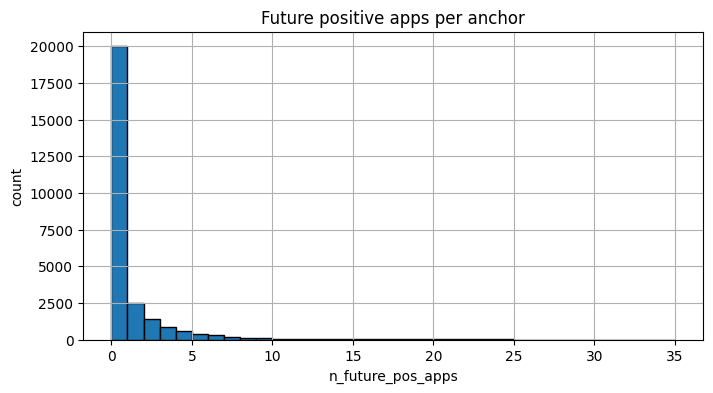

[val] fraction n_future_pos_apps == 0: 0.826856292376385
[val] users with exactly 1 val thumbs-up (among anchor users): 15989/20000
[val] anchors with ≥1 future app: 4188/24188


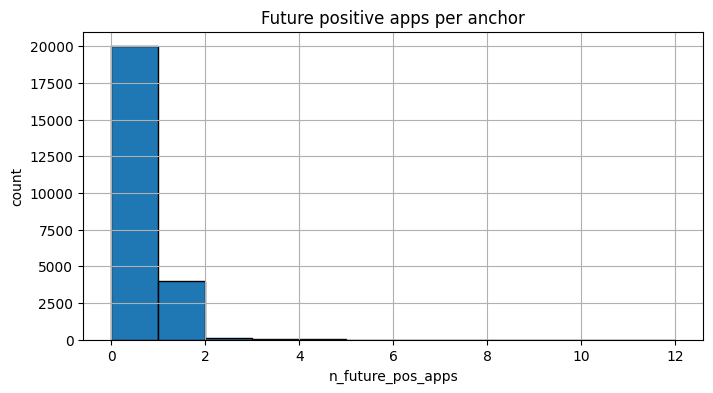

In [4]:
def summarize_future_labels(
    anchors_df: pd.DataFrame,
    split_reviews: pd.DataFrame,
    *,
    user_col: str,
    split_label: str = "train",
) -> None:
    fraction_zero_future = (
        float((anchors_df["n_future_pos_apps"] == 0).mean()) if len(anchors_df) else float("nan")
    )
    print(f"[{split_label}] fraction n_future_pos_apps == 0:", fraction_zero_future)
    anchor_user_ids = anchors_df[user_col].unique()
    positive_review_counts_per_user = (
        split_reviews.loc[split_reviews["recommended"] == 1]
        .groupby(user_col, sort=False)
        .size()
        .reindex(anchor_user_ids)
    )
    num_users_single_positive = int((positive_review_counts_per_user == 1).sum())
    print(
        f"[{split_label}] users with exactly 1 {split_label} thumbs-up (among anchor users):",
        f"{num_users_single_positive}/{len(anchor_user_ids)}",
    )
    num_anchors_with_future = int((anchors_df["n_future_pos_apps"] > 0).sum())
    print(f"[{split_label}] anchors with ≥1 future app: {num_anchors_with_future}/{len(anchors_df)}")


def plot_future_histogram(anchors_df: pd.DataFrame) -> None:
    if anchors_df.empty:
        return
    max_future_app_count = int(anchors_df["n_future_pos_apps"].max())
    plt.figure(figsize=(8, 4))
    anchors_df["n_future_pos_apps"].hist(bins=range(0, max_future_app_count + 2), edgecolor="black")
    plt.xlabel("n_future_pos_apps")
    plt.ylabel("count")
    plt.title("Future positive apps per anchor")
    plt.show()


summarize_future_labels(anchors, df_train, user_col=USER_COL, split_label="train")
plot_future_histogram(anchors)
summarize_future_labels(anchors_val, df_val, user_col=USER_COL, split_label="val")
plot_future_histogram(anchors_val)


## Tower training (TensorFlow)

**Rows:** one per `(anchor, future liked app)`; `group_id` ties multi-positive labels from the same anchor.

**Training:** `training_mode="full"` = full train/val pass per epoch + early stopping on `val_loss`. `"smoke"` = 1 batch per epoch for wiring checks.

**Post-training eval (step 2):** score on cached **Task A** `eval_examples.parquet` (not causal val anchors, not `val_loss`). Metrics by **slice A/B** and **`train_support_bucket`** per `recs_job_eval_retrieval` contract.

**Updated user path:** Hub `trainable=True` (encoder weights update). `jit_compile=False`; string inputs encoded on CPU.

**Updated item path:** trainable item embedding table initialized from profile-mean vectors (up to 200 reviews/game); fallback to `recs_002` when profile rows are missing.


In [5]:
def future_positive_app_ids(row: pd.Series) -> list[int]:
    raw_ids = row["future_positive_app_ids"]
    if isinstance(raw_ids, (list, tuple)):
        return [int(app_id) for app_id in raw_ids]
    return [int(app_id) for app_id in list(raw_ids)]


def load_hub_settings(retriever: ContentRetriever) -> tuple[str, int | None]:
    _, _, meta_path = retriever._artifact_paths()
    meta = json.loads(meta_path.read_text(encoding="utf-8"))
    return str(meta["model_name"]), meta.get("max_chars_per_review")


def clip_text(text: str, max_chars: int | None) -> str:
    cleaned = (text or "").strip()
    if max_chars is None:
        return cleaned
    return cleaned[: int(max_chars)]


def build_app_mean_use_lookup(
    profile_parquet: Path,
    retriever: ContentRetriever,
    *,
    max_chars: int | None,
    max_reviews_per_game: int,
    embed_batch_size: int,
) -> dict[int, np.ndarray]:
    """Mean-pool up to N USE(review) vectors per app, L2-normalize (recs_002-style)."""
    profile_df = pd.read_parquet(profile_parquet, columns=["app_id", "review"])
    retriever._ensure_embedder()

    app_mean: dict[int, np.ndarray] = {}
    grouped = profile_df.groupby("app_id", sort=False)["review"]
    for app_id, reviews in tqdm(grouped, desc="mean-pool profile USE per app"):
        non_empty = [
            clip_text(str(text), max_chars)
            for text in reviews.fillna("").astype(str).tolist()
            if str(text).strip()
        ]
        texts = non_empty[: int(max_reviews_per_game)]
        if not texts:
            continue

        batch_vectors: list[np.ndarray] = []
        for start in range(0, len(texts), int(embed_batch_size)):
            batch_texts = texts[start : start + int(embed_batch_size)]
            raw_batch = retriever._embed_fn(batch_texts).numpy().astype(np.float32)
            batch_vectors.append(l2_normalize_rows(raw_batch))
        vectors = np.vstack(batch_vectors)
        app_mean[int(app_id)] = l2_normalize(vectors.mean(axis=0))

    if len(app_mean) < 2:
        raise RuntimeError("Need >= 2 apps with profile reviews for mean-pooled item vectors.")
    return app_mean


def catalog_matrix_from_mean_lookup(
    app_ids: np.ndarray,
    app_mean_use_lookup: dict[int, np.ndarray],
    fallback_matrix: np.ndarray,
) -> np.ndarray:
    rows: list[np.ndarray] = []
    for row_index, app_id in enumerate(app_ids.tolist()):
        vector = app_mean_use_lookup.get(int(app_id))
        if vector is None:
            rows.append(np.asarray(fallback_matrix[row_index], dtype=np.float32))
        else:
            rows.append(np.asarray(vector, dtype=np.float32))
    return np.stack(rows, axis=0)


def catalog_app_row_map(retriever: ContentRetriever) -> dict[int, int]:
    return {int(app_id): row_index for row_index, app_id in enumerate(np.asarray(retriever.app_ids).tolist())}


def build_tower_rows(
    anchors_df: pd.DataFrame,
    retriever: ContentRetriever,
    spec: TowerSpec,
    *,
    max_anchors: int,
    max_chars: int | None,
) -> tuple:
    supervised = anchors_df.loc[anchors_df["n_future_pos_apps"] > 0].iloc[:max_anchors]
    app_to_row = catalog_app_row_map(retriever)

    user_rows: list[np.ndarray] = []
    user_texts: list[str] = []
    item_row_ids: list[int] = []
    group_ids: list[int] = []
    group_id = 0

    for _, anchor_row in supervised.iterrows():
        app_ids = [app_id for app_id in future_positive_app_ids(anchor_row) if app_id in app_to_row]
        if not app_ids:
            continue
        anchor_text = clip_text(str(anchor_row["anchor_review_text"]), max_chars)
        if spec.user_mode == "frozen":
            user_embedding = np.asarray(retriever.embed_text(anchor_text), dtype=np.float32)
        for app_id in app_ids:
            if spec.user_mode == "frozen":
                user_rows.append(user_embedding)
            else:
                user_texts.append(anchor_text)
            item_row_ids.append(int(app_to_row[int(app_id)]))
            group_ids.append(group_id)
        group_id += 1

    if len(item_row_ids) < 2:
        raise RuntimeError(f"{spec.label}: need >= 2 rows after join.")
    item_rows = np.asarray(item_row_ids, dtype=np.int32)
    group_arr = np.asarray(group_ids, dtype=np.int32)
    if spec.user_mode == "frozen":
        return np.stack(user_rows), item_rows, group_arr
    return np.asarray(user_texts, dtype=object), item_rows, group_arr


def multi_positive_inbatch_loss(similarity_logits, group_ids):
    """`-log sum_{positives} exp(sim) / sum_{batch} exp(sim)` averaged over rows."""
    group_ids_column = tf.expand_dims(group_ids, 1)
    group_ids_row = tf.expand_dims(group_ids, 0)
    positive_mask = tf.cast(tf.equal(group_ids_column, group_ids_row), tf.float32)
    log_normalizer = tf.reduce_logsumexp(similarity_logits, axis=1)
    masked_logits = similarity_logits + (positive_mask - 1.0) * 1e9
    log_positive_sum = tf.reduce_logsumexp(masked_logits, axis=1)
    return tf.reduce_mean(-(log_positive_sum - log_normalizer))


def contrastive_loss_from_vectors(user_vectors, item_vectors, group_ids, temperature):
    user_norm = tf.math.l2_normalize(user_vectors, axis=1)
    item_norm = tf.math.l2_normalize(item_vectors, axis=1)
    logits = tf.matmul(user_norm, item_norm, transpose_b=True) / temperature
    user_to_item = multi_positive_inbatch_loss(logits, group_ids)
    item_to_user = multi_positive_inbatch_loss(tf.transpose(logits), group_ids)
    total = 0.5 * (user_to_item + item_to_user)
    return total, user_to_item, item_to_user


def make_frozen_user_dataset(user_embeddings, item_row_ids, group_ids, batch_size, shuffle_seed):
    return (
        tf.data.Dataset.from_tensor_slices(
            (
                user_embeddings.astype(np.float32),
                item_row_ids.astype(np.int32),
                group_ids.astype(np.int32),
            )
        )
        .shuffle(int(user_embeddings.shape[0]), seed=shuffle_seed)
        .batch(batch_size, drop_remainder=True)
        .map(
            lambda user_batch, item_row_batch, group_batch: {
                "user": user_batch,
                "item_row_id": item_row_batch,
                "group_id": group_batch,
            }
        )
    )


def make_updated_user_dataset(user_texts, item_row_ids, group_ids, batch_size, shuffle_seed):
    return (
        tf.data.Dataset.from_tensor_slices(
            (
                tf.constant(list(user_texts), dtype=tf.string),
                item_row_ids.astype(np.int32),
                group_ids.astype(np.int32),
            )
        )
        .shuffle(int(len(user_texts)), seed=shuffle_seed)
        .batch(batch_size, drop_remainder=True)
        .map(
            lambda user_batch, item_row_batch, group_batch: {
                "user_text": user_batch,
                "item_row_id": item_row_batch,
                "group_id": group_batch,
            }
        )
    )


def l2_normalize_rows(matrix: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    mat = np.asarray(matrix, dtype=np.float32)
    norms = np.linalg.norm(mat, axis=1, keepdims=True)
    norms = np.maximum(norms, eps)
    return mat / norms


def tower_fit_kwargs(cfg: Recs012Config, n_train_rows: int, n_val_rows: int, batch_size: int) -> dict:
    if cfg.training_mode == "smoke":
        return {
            "epochs": int(cfg.smoke_epochs),
            "steps_per_epoch": 1,
            "validation_steps": 1,
        }
    steps_train = max(1, int(n_train_rows) // int(batch_size))
    steps_val = max(1, int(n_val_rows) // int(batch_size))
    return {
        "epochs": int(cfg.epochs),
        "steps_per_epoch": steps_train,
        "validation_steps": steps_val,
    }


def precompute_catalog_item_vectors(
    spec: TowerSpec,
    model,
    retriever: ContentRetriever,
    *,
    batch_size: int,
):
    app_ids = np.asarray(retriever.app_ids, dtype=np.int64)
    valid_mask_in = np.ones(app_ids.shape[0], dtype=bool)

    parts: list[np.ndarray] = []
    for start in range(0, app_ids.shape[0], batch_size):
        stop = start + batch_size
        item_row_batch = tf.constant(np.arange(start, min(stop, app_ids.shape[0])), dtype=tf.int32)
        parts.append(model.encode_item_by_row_ids(item_row_batch).numpy())
    item_vectors = np.vstack(parts).astype(np.float32, copy=False)
    return item_vectors, valid_mask_in, app_ids


def encode_anchor_user_vector(
    spec: TowerSpec,
    model,
    retriever: ContentRetriever,
    anchor_text: str,
    *,
    max_chars: int | None,
):
    if spec.user_mode == "frozen":
        frozen = np.asarray(retriever.embed_text(clip_text(anchor_text, max_chars)), dtype=np.float32)
        return model.user_projection(tf.constant(frozen[None], dtype=tf.float32)).numpy()[0]
    text_batch = tf.constant([clip_text(anchor_text, max_chars)], dtype=tf.string)
    return model.encode_user(text_batch).numpy()[0]


def score_catalog(
    user_vector: np.ndarray,
    item_vectors: np.ndarray,
    valid_mask: np.ndarray,
    *,
    mask_row: int | None,
) -> np.ndarray:
    user_unit = l2_normalize(user_vector.astype(np.float32, copy=False))
    item_unit = l2_normalize_rows(item_vectors)
    scores = item_unit @ user_unit
    scores = scores.astype(np.float64, copy=False)
    scores[~valid_mask] = -np.inf
    if mask_row is not None and 0 <= int(mask_row) < scores.shape[0]:
        scores[int(mask_row)] = -np.inf
    return scores


def retrieval_eval_slice_name(n_eval_targets: int) -> str:
    """Align with recs_011 / recommendation_evaluation_overview.md (Task A n_eval_targets)."""
    if int(n_eval_targets) >= 2:
        return "slice_a_multi_target"
    if int(n_eval_targets) == 1:
        return "slice_b_single_target"
    return "slice_c_zero_target"


def annotate_retrieval_slices(per_anchor_df: pd.DataFrame) -> pd.DataFrame:
    out = per_anchor_df.copy()
    if "slice_name" in out.columns:
        return out
    target_col = "n_eval_targets" if "n_eval_targets" in out.columns else "n_future_pos_apps"
    out["slice_name"] = out[target_col].map(lambda n: retrieval_eval_slice_name(int(n)))
    return out


def summarize_retrieval_contract(per_anchor_df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    df = per_anchor_df.copy()
    if "label" not in df.columns and "method" in df.columns:
        df = df.rename(columns={"method": "label"})
    overall = df.groupby("label", as_index=False)[RETRIEVAL_METRIC_COLS].mean()
    by_slice = (
        df.groupby(["label", "slice_name"], as_index=False)[RETRIEVAL_METRIC_COLS]
        .mean()
        .sort_values(["slice_name", "label"])
    )
    return overall, by_slice


def print_retrieval_coverage(per_anchor_df: pd.DataFrame, *, k: int) -> None:
    eval_rows = per_anchor_df[per_anchor_df["slice_name"] != "slice_c_zero_target"]
    counts = eval_rows["slice_name"].value_counts()
    print(f"retrieval eval anchors (k_retrieval={k}):", len(eval_rows))
    for slice_name, count in counts.items():
        print(f"  {slice_name}: {int(count)}")


def pick_tower_winner_by_contract(by_slice: pd.DataFrame) -> str | None:
    """Best Recall@K on slice A among tower labels; tie-break Precision@K, Hit@K."""
    towers = by_slice[~by_slice["label"].eq("USE_baseline")]
    slice_a = towers[towers["slice_name"].eq("slice_a_multi_target")].copy()
    if slice_a.empty:
        return None
    slice_a = slice_a.sort_values(["Recall@K", "Precision@K", "Hit@K"], ascending=False)
    return str(slice_a.iloc[0]["label"])


def eval_retrieval_on_val_anchors(
    spec: TowerSpec,
    model,
    retriever: ContentRetriever,
    anchors_val_df: pd.DataFrame,
    cfg: Recs012Config,
    *,
    max_chars: int | None,
) -> pd.DataFrame:
    app_to_row = catalog_app_row_map(retriever)
    item_vectors, valid_mask, app_ids = precompute_catalog_item_vectors(
        spec,
        model,
        retriever,
        batch_size=int(cfg.catalog_item_batch),
    )

    supervised = anchors_val_df.loc[anchors_val_df["n_future_pos_apps"] > 0].iloc[: int(cfg.max_val_anchors_eval)]
    k = int(cfg.k_retrieval)
    rows: list[dict] = []

    for _, anchor_row in tqdm(supervised.iterrows(), total=len(supervised), desc=f"retrieval {spec.label}"):
        positives = {app_id for app_id in future_positive_app_ids(anchor_row) if app_id in app_to_row}
        if not positives:
            continue
        user_vector = encode_anchor_user_vector(
            spec,
            model,
            retriever,
            str(anchor_row["anchor_review_text"]),
            max_chars=max_chars,
        )
        mask_row = app_to_row.get(int(anchor_row["anchor_app_id"])) if cfg.mask_anchor_app_in_scores else None
        scores = score_catalog(user_vector, item_vectors, valid_mask, mask_row=mask_row)
        ranked_rows = np.argsort(-scores)
        rows.append(
            {
                "label": spec.label,
                "user_mode": spec.user_mode,
                "item_mode": spec.item_mode,
                "anchor_review_id": int(anchor_row["anchor_review_id"]),
                "n_state_pos_reviews": int(anchor_row["n_state_pos_reviews"]),
                "n_future_pos_apps": int(anchor_row["n_future_pos_apps"]),
                "Hit@K": hit_rate_at_k(ranked_rows, positives, k, app_ids),
                "Precision@K": precision_at_k(ranked_rows, positives, k, app_ids),
                "Recall@K": recall_at_k(ranked_rows, positives, k, app_ids),
            }
        )

    if not rows:
        raise RuntimeError(f"No retrieval rows for {spec.label}")
    return pd.DataFrame(rows)


def eval_frozen_use_baseline(
    retriever: ContentRetriever,
    anchors_val_df: pd.DataFrame,
    cfg: Recs012Config,
    *,
    max_chars: int | None,
) -> pd.DataFrame:
    app_to_row = catalog_app_row_map(retriever)
    catalog_unit = l2_normalize_rows(np.asarray(retriever.embedding_matrix, dtype=np.float32))
    app_ids = np.asarray(retriever.app_ids, dtype=np.int64)
    supervised = anchors_val_df.loc[anchors_val_df["n_future_pos_apps"] > 0].iloc[: int(cfg.max_val_anchors_eval)]
    k = int(cfg.k_retrieval)
    rows: list[dict] = []

    for _, anchor_row in tqdm(supervised.iterrows(), total=len(supervised), desc="retrieval USE_baseline"):
        positives = {app_id for app_id in future_positive_app_ids(anchor_row) if app_id in app_to_row}
        if not positives:
            continue
        user_unit = l2_normalize(
            np.asarray(retriever.embed_text(clip_text(str(anchor_row["anchor_review_text"]), max_chars)), dtype=np.float32)
        )
        scores = catalog_unit @ user_unit
        if cfg.mask_anchor_app_in_scores:
            mask_row = app_to_row.get(int(anchor_row["anchor_app_id"]))
            if mask_row is not None:
                scores[int(mask_row)] = -np.inf
        ranked_rows = np.argsort(-scores)
        rows.append(
            {
                "label": "USE_baseline",
                "user_mode": "baseline",
                "item_mode": "catalog",
                "anchor_review_id": int(anchor_row["anchor_review_id"]),
                "n_state_pos_reviews": int(anchor_row["n_state_pos_reviews"]),
                "n_future_pos_apps": int(anchor_row["n_future_pos_apps"]),
                "Hit@K": hit_rate_at_k(ranked_rows, positives, k, app_ids),
                "Precision@K": precision_at_k(ranked_rows, positives, k, app_ids),
                "Recall@K": recall_at_k(ranked_rows, positives, k, app_ids),
            }
        )

    return pd.DataFrame(rows)


def _task_a_examples_for_eval(eval_inputs, cfg: Recs012Config) -> list[dict]:
    examples = list(eval_inputs.examples)
    if cfg.max_task_a_examples_eval is not None:
        examples = examples[: int(cfg.max_task_a_examples_eval)]
    return examples


def make_use_baseline_score_fn(
    retriever: ContentRetriever,
    eval_inputs,
    cfg: Recs012Config,
    *,
    max_chars: int | None,
):
    catalog_unit = l2_normalize_rows(np.asarray(eval_inputs.embedding_matrix, dtype=np.float32))
    app_to_row = eval_inputs.app_to_row

    def score_fn(ex: dict) -> np.ndarray:
        user_unit = l2_normalize(
            np.asarray(retriever.embed_text(clip_text(str(ex["query_text"]), max_chars)), dtype=np.float32)
        )
        scores = catalog_unit @ user_unit
        scores = scores.astype(np.float64, copy=False)
        if cfg.mask_anchor_app_in_scores:
            mask_row = app_to_row.get(int(ex["query_app_id"]))
            if mask_row is not None:
                scores[int(mask_row)] = -np.inf
        return scores

    return score_fn


def make_tower_score_fn(
    spec: TowerSpec,
    model,
    retriever: ContentRetriever,
    eval_inputs,
    cfg: Recs012Config,
    *,
    max_chars: int | None,
):
    item_vectors, valid_mask, _app_ids = precompute_catalog_item_vectors(
        spec,
        model,
        retriever,
        batch_size=int(cfg.catalog_item_batch),
    )
    app_to_row = eval_inputs.app_to_row

    def score_fn(ex: dict) -> np.ndarray:
        user_vector = encode_anchor_user_vector(
            spec,
            model,
            retriever,
            str(ex["query_text"]),
            max_chars=max_chars,
        )
        mask_row = app_to_row.get(int(ex["query_app_id"])) if cfg.mask_anchor_app_in_scores else None
        return score_catalog(user_vector, item_vectors, valid_mask, mask_row=mask_row)

    return score_fn


def run_task_a_retrieval_eval(
    *,
    label: str,
    score_fn,
    eval_inputs,
    cfg: Recs012Config,
    retriever: ContentRetriever,
    verbose: bool = True,
) -> pd.DataFrame:
    examples = _task_a_examples_for_eval(eval_inputs, cfg)
    df_retrieval, _df_ranking, _artifacts = _per_example_retrieval_ranking(
        method_name=label,
        score_fn=score_fn,
        examples=examples,
        app_ids=eval_inputs.app_ids,
        k_retrieval=int(cfg.k_retrieval),
        k_final=int(cfg.k_final),
        masking_policy_version=MASKING_POLICY_VERSION,
        model_version=_embedding_model_snapshot(retriever),
        verbose=verbose,
    )
    return df_retrieval.rename(columns={"method": "label"})


def summarize_task_a_retrieval(per_anchor_df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    df = annotate_retrieval_slices(per_anchor_df)
    overall, by_slice = summarize_retrieval_contract(df)
    by_support = _table_by_support_for_metrics(
        df.rename(columns={"label": "method"}),
        metric_cols=RETRIEVAL_METRIC_COLS,
        ranking=False,
    ).rename(columns={"method": "label"})
    return overall, by_slice, by_support


def train_tower_spec(
    spec: TowerSpec,
    train_payload: tuple,
    val_payload: tuple,
    cfg: Recs012Config,
    *,
    hub_url: str,
    item_init_matrix: np.ndarray,
):
    import os

    import tensorflow as tf
    import tensorflow_hub as hub
    from tensorflow import keras

    os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
    if spec.user_mode == "updated":
        tf.config.optimizer.set_jit(False)

    batch_size = int(cfg.batch_size)
    projection_dim = int(cfg.proj_dim)
    temperature = float(cfg.temperature)
    seed = int(cfg.tower_seed)
    user_updated = spec.user_mode == "updated"
    item_updated = spec.item_mode == "updated_profile200"
    trainable_use = user_updated

    class TwoTowerModel(keras.Model):
        def __init__(self):
            super().__init__(name=f"tower_{spec.label}")
            if user_updated:
                self.user_encoder = hub.KerasLayer(hub_url, trainable=trainable_use, name="user_use")
            self.user_projection = keras.layers.Dense(projection_dim)
            self.item_projection = keras.layers.Dense(projection_dim)
            self.item_base = self.add_weight(
                name="item_base_embeddings",
                shape=item_init_matrix.shape,
                initializer=keras.initializers.Constant(item_init_matrix),
                trainable=item_updated,
            )

        def encode_user(self, texts):
            with tf.device("/CPU:0"):
                encoded = self.user_encoder(texts)
            return self.user_projection(encoded)

        def encode_item_by_row_ids(self, item_row_ids):
            item_base_vectors = tf.gather(self.item_base, item_row_ids)
            return self.item_projection(item_base_vectors)

        def _user_vectors(self, batch):
            if user_updated:
                return self.encode_user(batch["user_text"])
            return self.user_projection(batch["user"])

        def train_step(self, batch):
            with tf.GradientTape() as tape:
                user_vectors = self._user_vectors(batch)
                item_vectors = self.encode_item_by_row_ids(batch["item_row_id"])
                loss, u2i, i2u = contrastive_loss_from_vectors(
                    user_vectors, item_vectors, batch["group_id"], temperature
                )
            grads = tape.gradient(loss, self.trainable_variables)
            self.optimizer.apply_gradients(zip(grads, self.trainable_variables))
            return {"loss": loss, "user_to_item_loss": u2i, "item_to_user_loss": i2u}

        def test_step(self, batch):
            user_vectors = self._user_vectors(batch)
            item_vectors = self.encode_item_by_row_ids(batch["item_row_id"])
            loss, u2i, i2u = contrastive_loss_from_vectors(
                user_vectors, item_vectors, batch["group_id"], temperature
            )
            return {"loss": loss, "user_to_item_loss": u2i, "item_to_user_loss": i2u}

    model = TwoTowerModel()
    if spec.user_mode == "frozen":
        train_ds = make_frozen_user_dataset(*train_payload, batch_size, seed)
        val_ds = make_frozen_user_dataset(*val_payload, batch_size, seed + 1)
    else:
        train_ds = make_updated_user_dataset(*train_payload, batch_size, seed)
        val_ds = make_updated_user_dataset(*val_payload, batch_size, seed + 1)

    train_row_count = len(train_payload[0])
    val_row_count = len(val_payload[0])
    if train_row_count < batch_size or val_row_count < batch_size:
        raise RuntimeError(
            f"{spec.label}: need >= {batch_size} train/val rows; got train={train_row_count}, val={val_row_count}."
        )

    fit_kwargs = tower_fit_kwargs(cfg, train_row_count, val_row_count, batch_size)
    print(
        f"{spec.label}: train rows={train_row_count} val rows={val_row_count} "
        f"user={spec.user_mode} item={spec.item_mode} user_encoder_trainable={trainable_use} "
        f"item_encoder_trainable={item_updated} mode={cfg.training_mode} "
        f"steps/epoch={fit_kwargs['steps_per_epoch']} val_steps={fit_kwargs['validation_steps']} "
        f"epochs={fit_kwargs['epochs']}"
    )
    callbacks = []
    if cfg.training_mode == "full":
        callbacks.append(
            keras.callbacks.EarlyStopping(
                monitor="val_loss",
                patience=int(cfg.early_stopping_patience),
                restore_best_weights=True,
            )
        )
    model.compile(
        optimizer=keras.optimizers.Adam(cfg.adam_lr),
        jit_compile=False,
    )
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        callbacks=callbacks,
        verbose=1,
        **fit_kwargs,
    )
    return model, history


import os

import tensorflow as tf

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

hub_url, hub_max_chars = load_hub_settings(retriever)
print("Building mean-pooled USE vectors per game (updated_profile200 item modes)...")
app_mean_use_lookup = build_app_mean_use_lookup(
    CFG.game_profile_reviews_parquet,
    retriever,
    max_chars=hub_max_chars,
    max_reviews_per_game=int(CFG.max_profile_reviews_per_game),
    embed_batch_size=int(CFG.profile_embed_batch_size),
)
print("apps with mean-pooled item vectors:", len(app_mean_use_lookup))

catalog_matrix = np.asarray(retriever.embedding_matrix, dtype=np.float32)
profile200_init_matrix = catalog_matrix_from_mean_lookup(
    np.asarray(retriever.app_ids, dtype=np.int64),
    app_mean_use_lookup,
    fallback_matrix=catalog_matrix,
)

item_init_matrix_by_mode = {
    "frozen_recs002": catalog_matrix,
    "updated_profile200": profile200_init_matrix,
}


def tower_grid_summary_table(specs: tuple[TowerSpec, ...]) -> pd.DataFrame:
    item_init_source = {
        "frozen_recs002": "recs_002 catalog NPZ",
        "updated_profile200": (
            f"mean-pooled USE (≤{CFG.max_profile_reviews_per_game} reviews/game); "
            "missing profile → recs_002 fallback"
        ),
    }
    rows = [
        {
            "label": spec.label,
            "user_mode": spec.user_mode,
            "item_mode": spec.item_mode,
            "user_encoder_trainable": spec.user_mode == "updated",
            "item_encoder_trainable": spec.item_mode == "updated_profile200",
            "item_init_source": item_init_source[spec.item_mode],
        }
        for spec in specs
    ]
    return pd.DataFrame(rows)


tower_specs = CFG.resolve_tower_specs()
print("=== two-tower grid (this run) ===")
display(tower_grid_summary_table(tower_specs))

tower_anchor_cap = min(CFG.max_rows_tower, int((anchors["n_future_pos_apps"] > 0).sum()))
val_anchor_cap = min(CFG.max_rows_tower, int((anchors_val["n_future_pos_apps"] > 0).sum()))

variant_histories: dict[str, tf.keras.callbacks.History] = {}
variant_models: dict[str, tf.keras.Model] = {}

for spec in tower_specs:
    print("\n===", spec.label, "===")
    train_payload = build_tower_rows(
        anchors,
        retriever,
        spec,
        max_anchors=tower_anchor_cap,
        max_chars=hub_max_chars,
    )
    val_payload = build_tower_rows(
        anchors_val,
        retriever,
        spec,
        max_anchors=val_anchor_cap,
        max_chars=hub_max_chars,
    )
    model, history = train_tower_spec(
        spec,
        train_payload,
        val_payload,
        CFG,
        hub_url=hub_url,
        item_init_matrix=item_init_matrix_by_mode[spec.item_mode],
    )
    variant_histories[spec.label] = history
    variant_models[spec.label] = model

print("\n=== Task A retrieval eval (cached eval_examples.parquet; post-training) ===")
if not CFG.eval_examples_parquet.is_file():
    raise FileNotFoundError(
        f"Missing {CFG.eval_examples_parquet}. Run: "
        "python scripts/recs_job_build_eval_examples.py configs/recs_job_build_eval_examples.json"
    )

task_a_eval_inputs = prepare_eval_inputs_from_cache(
    repo_root=CFG.repo_root,
    split="val",
    min_review_chars=CFG.min_review_chars,
    examples_parquet=CFG.eval_examples_parquet,
    verbose=True,
)
task_a_n = len(_task_a_examples_for_eval(task_a_eval_inputs, CFG))
print(f"scoring {task_a_n:,} Task A examples (k_retrieval={CFG.k_retrieval})")

task_a_retrieval_frames: list[pd.DataFrame] = [
    run_task_a_retrieval_eval(
        label="USE_baseline",
        score_fn=make_use_baseline_score_fn(
            retriever, task_a_eval_inputs, CFG, max_chars=hub_max_chars
        ),
        eval_inputs=task_a_eval_inputs,
        cfg=CFG,
        retriever=retriever,
        verbose=True,
    )
]
for spec in tower_specs:
    task_a_retrieval_frames.append(
        run_task_a_retrieval_eval(
            label=spec.label,
            score_fn=make_tower_score_fn(
                spec,
                variant_models[spec.label],
                retriever,
                task_a_eval_inputs,
                CFG,
                max_chars=hub_max_chars,
            ),
            eval_inputs=task_a_eval_inputs,
            cfg=CFG,
            retriever=retriever,
            verbose=True,
        )
    )

task_a_retrieval_per_anchor = pd.concat(task_a_retrieval_frames, ignore_index=True)
variant_retrieval_per_anchor = task_a_retrieval_per_anchor  # alias for downstream cells

print_retrieval_coverage(task_a_retrieval_per_anchor, k=int(CFG.k_retrieval))
task_a_retrieval_overall, task_a_retrieval_by_slice, task_a_retrieval_by_support = summarize_task_a_retrieval(
    task_a_retrieval_per_anchor
)
variant_retrieval_overall = task_a_retrieval_overall
variant_retrieval_by_slice = task_a_retrieval_by_slice

print("=== Task A retrieval by slice (primary gate) ===")
display(task_a_retrieval_by_slice)

print("=== Task A retrieval by train_support_bucket ===")
display(task_a_retrieval_by_support)

print("=== Task A retrieval overall (secondary) ===")
display(task_a_retrieval_overall.sort_values("Recall@K", ascending=False))

contract_winner = pick_tower_winner_by_contract(task_a_retrieval_by_slice)
if contract_winner:
    slice_b_row = task_a_retrieval_by_slice[
        (task_a_retrieval_by_slice["label"] == contract_winner)
        & (task_a_retrieval_by_slice["slice_name"] == "slice_b_single_target")
    ]
    hit_b = float(slice_b_row["Hit@K"].iloc[0]) if len(slice_b_row) else float("nan")
    print(
        f"Contract pick (slice A primary Recall@K): {contract_winner} | "
        f"slice B Hit@K={hit_b:.4f} (check vs other cells)"
    )
else:
    print("Contract pick: no slice A examples in cohort")

last_label = tower_specs[-1].label
tower_history = variant_histories[last_label]
print(
    f"last grid cell {last_label}: epochs={len(tower_history.history['loss'])} "
    f"final train/val loss={tower_history.history['loss'][-1]:.4f} / {tower_history.history['val_loss'][-1]:.4f} "
    "(val_loss = causal contrastive only; not used for contract pick)"
)


2026-05-24 11:49:03.200161: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-24 11:49:03.251231: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779637743.259936  150387 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779637743.263776  150387 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779637743.309102  150387 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

Building mean-pooled USE vectors per game (updated_profile200 item modes)...


/home/ryanr/miniconda3/envs/tf_condaforge/lib/python3.11/site-packages/tensorflow_hub/__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version
I0000 00:00:1779637745.834124  150387 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5199 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070 Laptop GPU, pci bus id: 0000:02:00.0, compute capability: 12.0
mean-pool profile USE per app: 100%|██████████| 315/315 [00:23<00:00, 13.22it/s]

apps with mean-pooled item vectors: 315
=== two-tower grid (this run) ===


,label,user_mode,item_mode,user_encoder_trainable,item_encoder_trainable,item_init_source
0,frozen_user__frozen_recs002_item,frozen,frozen_recs002,False,False,recs_002 catalog NPZ
1,frozen_user__updated_profile200_item,frozen,updated_profile200,False,True,mean-pooled USE (≤200 reviews/game); missing p...
2,updated_user__frozen_recs002_item,updated,frozen_recs002,True,False,recs_002 catalog NPZ
3,updated_user__updated_profile200_item,updated,updated_profile200,True,True,mean-pooled USE (≤200 reviews/game); missing p...


...

=== Task A retrieval by train_support_bucket ===


,train_support_bucket,label,Hit@K,Precision@K,Recall@K
0,0,updated_user__frozen_recs002_item,0.442880,0.004429,0.442720
1,0,USE_baseline,0.437440,0.004374,0.437280
2,0,frozen_user__frozen_recs002_item,0.432320,0.004326,0.432320
3,0,frozen_user__updated_profile200_item,0.405120,0.004054,0.405120
4,0,updated_user__updated_profile200_item,0.402880,0.004032,0.402880
5,1,updated_user__frozen_recs002_item,0.451840,0.004518,0.451840
6,1,frozen_user__frozen_recs002_item,0.451520,0.004515,0.451520
7,1,USE_baseline,0.437440,0.004374,0.437440
8,1,updated_user__updated_profile200_item,0.412160,0.004122,0.412160
9,1,frozen_user__updated_profile200_item,0.402560,0.004026,0.402560


=== Task A retrieval overall (secondary) ===


,label,Hit@K,Precision@K,Recall@K
1,frozen_user__frozen_recs002_item,0.45464,0.004793,0.436886
3,updated_user__frozen_recs002_item,0.45352,0.004793,0.436094
0,USE_baseline,0.45296,0.004801,0.434516
4,updated_user__updated_profile200_item,0.42224,0.004446,0.403940
2,frozen_user__updated_profile200_item,0.41240,0.004330,0.395098


Contract pick (slice A primary Recall@K): updated_user__frozen_recs002_item | slice B Hit@K=0.4383 (check vs other cells)
last grid cell updated_user__updated_profile200_item: epochs=4 final train/val loss=3.7741 / 4.3052 (val_loss = causal contrastive only; not used for contract pick)


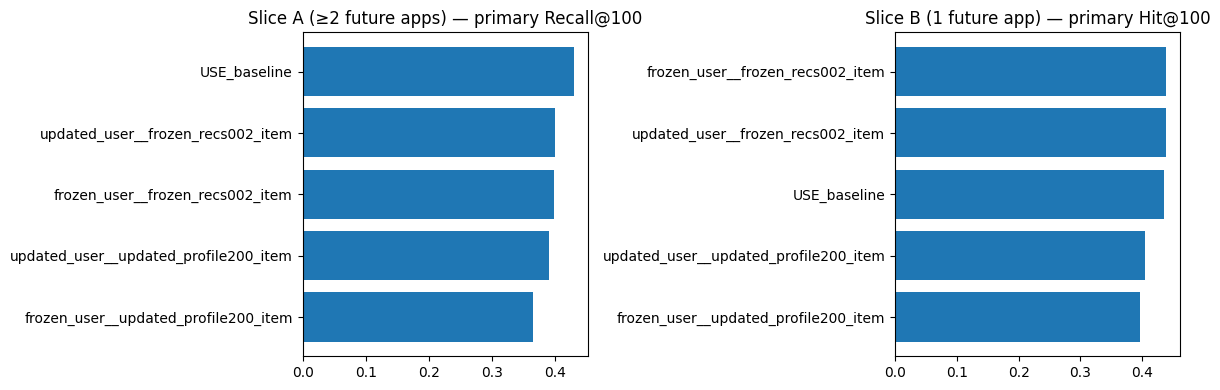

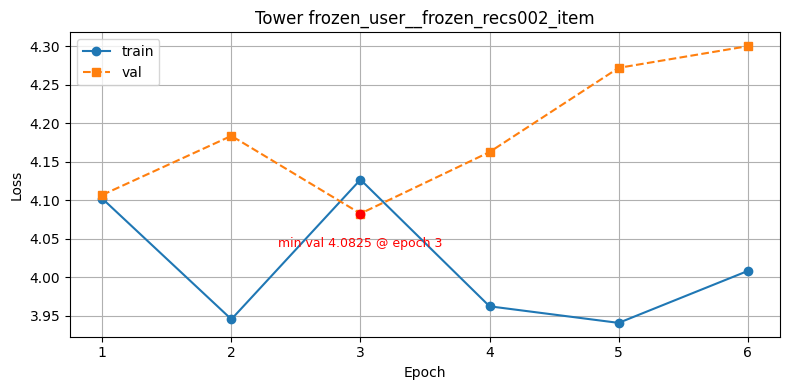

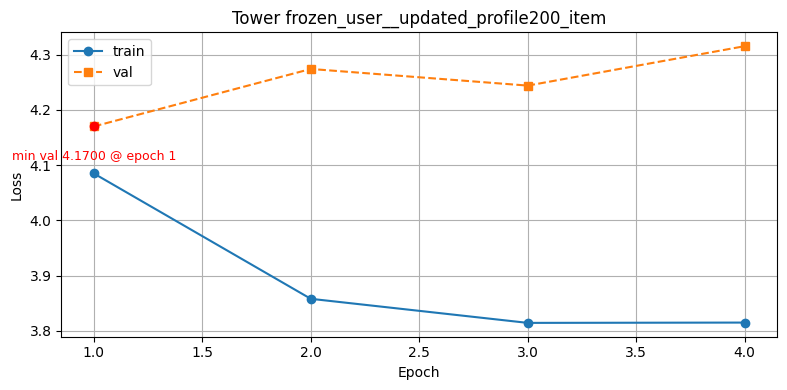

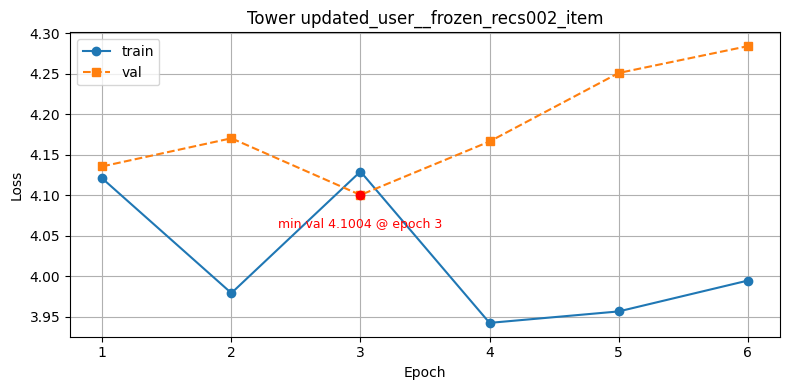

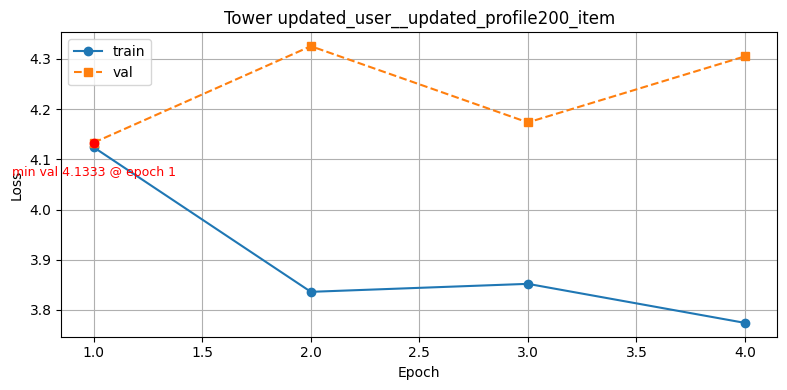

In [6]:
# Loss curves per grid cell + contract retrieval charts (slice A / B primaries)

if "variant_retrieval_by_slice" in dir():
    k = int(CFG.k_retrieval)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    slice_a = variant_retrieval_by_slice[
        variant_retrieval_by_slice["slice_name"] == "slice_a_multi_target"
    ].sort_values("Recall@K")
    slice_b = variant_retrieval_by_slice[
        variant_retrieval_by_slice["slice_name"] == "slice_b_single_target"
    ].sort_values("Hit@K")
    axes[0].barh(slice_a["label"], slice_a["Recall@K"])
    axes[0].set_title(f"Slice A (≥2 future apps) — primary Recall@{k}")
    axes[1].barh(slice_b["label"], slice_b["Hit@K"])
    axes[1].set_title(f"Slice B (1 future app) — primary Hit@{k}")
    plt.tight_layout()
    plt.show()

for label, history in variant_histories.items():
    steps = np.arange(1, len(history.history["loss"]) + 1)
    plt.figure(figsize=(8, 4))
    plt.plot(steps, history.history["loss"], marker="o", label="train")
    plt.plot(steps, history.history["val_loss"], marker="s", linestyle="--", label="val")
    val_losses = np.array(history.history["val_loss"])
    min_idx = int(np.argmin(val_losses))
    plt.scatter(steps[min_idx], val_losses[min_idx], color="red", zorder=5)
    plt.annotate(
        f"min val {val_losses[min_idx]:.4f} @ epoch {steps[min_idx]}",
        (steps[min_idx], val_losses[min_idx]),
        textcoords="offset points",
        xytext=(0, -24),
        ha="center",
        fontsize=9,
        color="red",
    )
    plt.title(f"Tower {label}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


## Task A: focus labels by `train_support_bucket`

Primary history breakdown is **`task_a_retrieval_by_support`** (from cached parquet; `n_support_train` = train reviews attached per example). Optional pivots below — run the tower + Task A eval cell first.

Hit@K by train_support_bucket (focus labels)


label,USE_baseline,frozen_user__frozen_recs002_item,frozen_user__updated_profile200_item
train_support_bucket,,,
0,0.437440,0.432320,0.405120
1,0.437440,0.451520,0.402560
2-3,0.436167,0.448906,0.390197
4-7,0.512694,0.492611,0.463054


Recall@K by train_support_bucket (focus labels)


label,USE_baseline,frozen_user__frozen_recs002_item,frozen_user__updated_profile200_item
train_support_bucket,,,
0,0.437280,0.432320,0.405120
1,0.437440,0.451520,0.402560
2-3,0.435936,0.448675,0.389689
4-7,0.425834,0.408831,0.381795


Delta (updated_profile200 − frozen_recs002); positive = profile200 wins:


,delta_Hit@K,delta_Recall@K
train_support_bucket,,
0,-0.027200,-0.027200
1,-0.048960,-0.048960
2-3,-0.058709,-0.058986
4-7,-0.029557,-0.027036


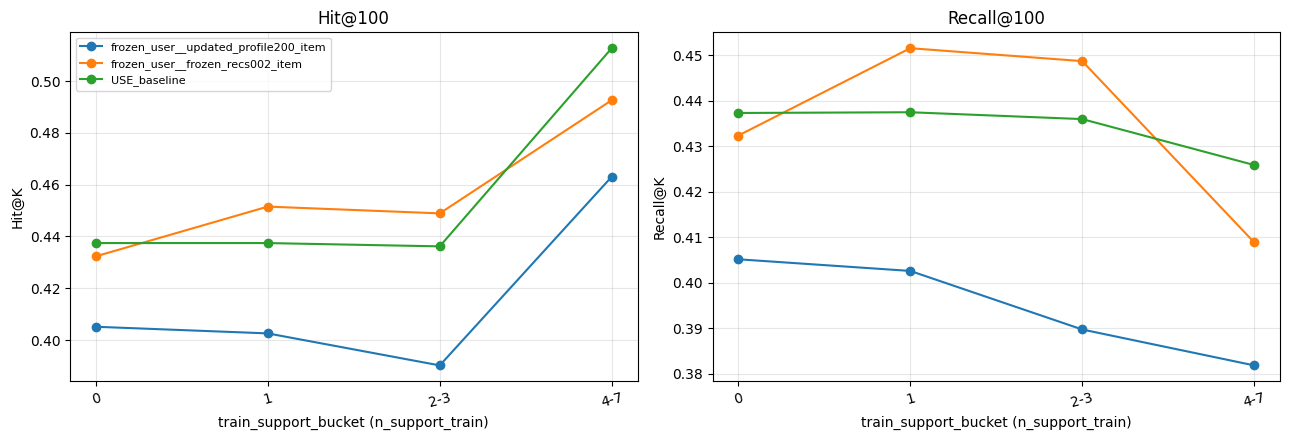

In [7]:
FOCUS_RETRIEVAL_LABELS = (
    "frozen_user__updated_profile200_item",
    "frozen_user__frozen_recs002_item",
    "USE_baseline",
)

if "task_a_retrieval_by_support" not in dir():
    raise RuntimeError("Run the tower training cell (Task A eval block) first.")

focus_support = task_a_retrieval_by_support[
    task_a_retrieval_by_support["label"].isin(FOCUS_RETRIEVAL_LABELS)
].copy()
pivot_hit = focus_support.pivot(index="train_support_bucket", columns="label", values="Hit@K")
pivot_recall = focus_support.pivot(index="train_support_bucket", columns="label", values="Recall@K")

print("Hit@K by train_support_bucket (focus labels)")
display(pivot_hit)

print("Recall@K by train_support_bucket (focus labels)")
display(pivot_recall)

if (
    "frozen_user__updated_profile200_item" in pivot_hit.columns
    and "frozen_user__frozen_recs002_item" in pivot_hit.columns
):
    print("Delta (updated_profile200 − frozen_recs002); positive = profile200 wins:")
    display(
        pd.DataFrame(
            {
                "delta_Hit@K": pivot_hit["frozen_user__updated_profile200_item"]
                - pivot_hit["frozen_user__frozen_recs002_item"],
                "delta_Recall@K": pivot_recall["frozen_user__updated_profile200_item"]
                - pivot_recall["frozen_user__frozen_recs002_item"],
            }
        )
    )

k = int(CFG.k_retrieval)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for axis, metric, title in zip(axes, ("Hit@K", "Recall@K"), (f"Hit@{k}", f"Recall@{k}")):
    for label in FOCUS_RETRIEVAL_LABELS:
        sub = focus_support.loc[focus_support["label"] == label]
        axis.plot(
            sub["train_support_bucket"].astype(str),
            sub[metric].values,
            marker="o",
            label=label,
        )
    axis.set_title(title)
    axis.set_xlabel("train_support_bucket (n_support_train)")
    axis.set_ylabel(metric)
    axis.tick_params(axis="x", rotation=15)
    axis.grid(True, alpha=0.3)
axes[0].legend(fontsize=8, loc="best")
plt.tight_layout()
plt.show()